## Setup

### Import Libraries

In [70]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from tqdm import tqdm

from torchvision import datasets
from torchvision import transforms

from pathlib import Path

from torch.utils.data import random_split
import pandas as pd

### Utility Functions

In [ ]:
n_in_features = 32 * 32 * 3  # CIFAR-10 images flattened
n_classes = 10  # CIFAR-10 has 10 classes

def create_deep_model(hidden_layer_sizes: list[int] = [1024, 512, 256, 128, 64, 32], SEED=2026) -> nn.Sequential:
    # create model
    torch.manual_seed(SEED)

    n_classes = 10

    layers = []
    input_size = n_features

    for hidden_layer_size in hidden_layer_sizes:
        layers.append(nn.Linear(input_size, hidden_layer_size))
        layers.append(nn.ReLU())
        input_size = hidden_layer_size

    layers.append(nn.Linear(input_size, n_classes))

    model = nn.Sequential(*layers)
    return model

def train(model: nn.Module, features_train: torch.Tensor, labels_train: torch.Tensor, learning_rate = 0.01, nepochs = 50) -> None:

    loss_function = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)

    losses = []
    accuracies = []
    for epoch in tqdm(range(nepochs)):
        optimizer.zero_grad()

        output = model.forward(features_train)

        loss = loss_function(output, labels_train)

        loss.backward()

        optimizer.step()

        losses.append(loss.item())
        accuracy = utils.calculate_accuracy(model, features_train, labels_train, verbose = False)
        accuracies.append(accuracy)
        if epoch % 10 == 0:
            print(f"Epoch: {epoch}, Loss: {loss:.2f}, Train accuracy: {accuracy:.2f}")


    return losses, accuracies

def calculate_accuracy(model: nn.Module, features: torch.Tensor, labels: torch.Tensor, verbose = True) -> torch.Tensor:

    output = model(features)
    accuracy = (labels == torch.argmax(output, dim=1)).sum()/len(labels)
    if verbose:
        print(f'Accuracy: {(accuracy*100).item()}')
    return (accuracy*100).item()

def plot_performance_training(losses, accuracies) -> None:

    fig, axes = plt.subplots(ncols = 2, figsize = (6, 3))

    axes[0].plot(losses)
    axes[0].set_title('Loss throughout training')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Cross-entropy loss')

    axes[1].plot(accuracies)
    axes[1].set_title('Accuracy on training data')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')

    fig.tight_layout()

class utils:
    create_deep_model = create_deep_model
    train = train
    calculate_accuracy = calculate_accuracy
    plot_performance_training = plot_performance_training

### Download Data

In [10]:
mean_cifar10 = (0.4914, 0.4822, 0.4465)
std_cifar10 = (0.2023, 0.1994, 0.2010)

# NOTE: Look up how the mean and std values for normalization are calculated exactly. Simply mean and std across all pixels and images in dataset?
train_data = datasets.CIFAR10(
    download=False,
    root="data",
    train=True,
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean_cifar10, std_cifar10)
    ])
)

test_data = datasets.CIFAR10(
    download=False,
    root="data",
    train=False,
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean_cifar10, std_cifar10)
    ])
)

Extract images and labels, normalize them, and flatten images to vectors for training.

In [25]:
# extract train data
features_train = torch.tensor(train_data.data) # get images used for training and put them in tensor
features_train = features_train.flatten(start_dim=1) # flatten images (n_images, 32, 32, 3) -> (n_images, 3072)
features_train = features_train / 255.0 # normalize pixel values from [0, 255] to [0, 1]

fraction_to_use = 0.05
n_to_use = int(len(features_train)*fraction_to_use)

features_train = features_train[:n_to_use]
labels_train = torch.tensor(train_data.targets)[:n_to_use]

# extract test data
features_test = torch.tensor(train_data.data) # get images used for training and put them in tensor
features_test = features_test.flatten(start_dim=1) # flatten images (n_images, 32, 32, 3) -> (n_images, 3072)
features_test = features_test / 255.0 # normalize pixel values from [0, 255] to [0, 1]

n_to_use = int(len(features_test)*fraction_to_use)

features_test = features_test[:n_to_use]
labels_test = torch.tensor(test_data.targets)[:n_to_use]


print(f"features_train shape: {features_train.shape}")
print(f"features_test shape: {features_test.shape}")
print(f"features_train min/max: {features_train.min():.2f} / {features_train.max():.2f}")

features_train shape: torch.Size([2500, 3072])
features_test shape: torch.Size([2500, 3072])
features_train min/max: 0.00 / 1.00


## Section 1: Effect of Making Networks Wider

Run cell below to define number of input features and number of classes to classify for models in this section and to create the SEED.

In [54]:
n_in_features = 32 * 32 * 3  # CIFAR-10 images flattened
n_classes = 10  # CIFAR-10 has 10 classes
SEED = 2026

**Example**: Create a model with a single neuron in the hidden layer (`hidden_layer_size = 1`) and a ReLU activation function after the hidden layer.

In [57]:
hidden_layer_size = 1

# create model
torch.manual_seed(SEED)

model = nn.Sequential(
    nn.Linear(n_in_features, hidden_layer_size),
    nn.ReLU(),
    nn.Linear(hidden_layer_size, n_classes)
)
model

Sequential(
  (0): Linear(in_features=3072, out_features=1, bias=True)
  (1): ReLU()
  (2): Linear(in_features=1, out_features=10, bias=True)
)

Train the model for 50 epochs using `utils.train`. Run the second cell to plot the accuracy and loss throughout training.

In [58]:
losses, accuracies = utils.train(model, features_train, labels_train, nepochs=50)

 38%|███▊      | 19/50 [00:00<00:00, 91.25it/s]

Epoch: 0, Loss: 2.47, Train accuracy: 10.00
Epoch: 10, Loss: 2.42, Train accuracy: 10.00


 92%|█████████▏| 46/50 [00:00<00:00, 117.59it/s]

Epoch: 20, Loss: 2.39, Train accuracy: 10.00
Epoch: 30, Loss: 2.36, Train accuracy: 10.00
Epoch: 40, Loss: 2.34, Train accuracy: 10.00


100%|██████████| 50/50 [00:00<00:00, 109.93it/s]


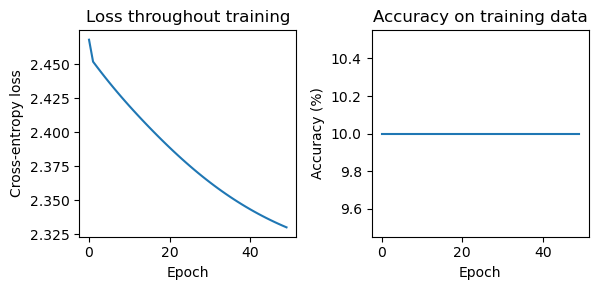

In [59]:
utils.plot_performance_training(losses, accuracies)

**Exercise**: Create a model with a 10 neurons in the hidden layer (`hidden_layer_size = 10`) and a ReLU activation function after the hidden layer.

In [61]:
hidden_layer_size = 10

# create model
torch.manual_seed(SEED)

model = nn.Sequential(
    nn.Linear(n_in_features, hidden_layer_size),
    nn.ReLU(),
    nn.Linear(hidden_layer_size, n_classes)
)
model

Sequential(
  (0): Linear(in_features=3072, out_features=10, bias=True)
  (1): ReLU()
  (2): Linear(in_features=10, out_features=10, bias=True)
)

Train the model for `50` epochs using `utils.train`. Run the second cell to plot the accuracy and loss throughout training.

In [62]:
losses, accuracies = utils.train(model, features_train, labels_train, nepochs=50)

 30%|███       | 15/50 [00:00<00:00, 76.16it/s]

Epoch: 0, Loss: 2.33, Train accuracy: 10.72
Epoch: 10, Loss: 2.33, Train accuracy: 9.44


 64%|██████▍   | 32/50 [00:00<00:00, 78.99it/s]

Epoch: 20, Loss: 2.32, Train accuracy: 9.44
Epoch: 30, Loss: 2.32, Train accuracy: 10.00


100%|██████████| 50/50 [00:00<00:00, 78.33it/s]

Epoch: 40, Loss: 2.31, Train accuracy: 10.00


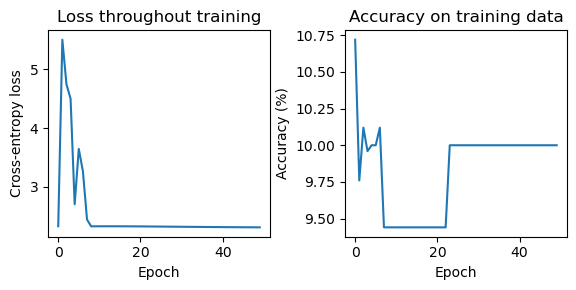

In [63]:
utils.plot_performance_training(losses, accuracies)

**Exercise**: Create a model with a 100 neurons in the hidden layer (`hidden_layer_size = 100`) and a ReLU activation function after the hidden layer.

In [150]:
hidden_layer_size = 1000

# create model
torch.manual_seed(SEED)

model = nn.Sequential(
    nn.Linear(n_in_features, hidden_layer_size),
    nn.ReLU(),
    nn.Linear(hidden_layer_size, n_classes)
)
model

Sequential(
  (0): Linear(in_features=3072, out_features=1000, bias=True)
  (1): ReLU()
  (2): Linear(in_features=1000, out_features=10, bias=True)
)

Train the model for `50` epochs using `utils.train`. Run the second cell to plot the accuracy and loss throughout training.

In [ ]:
losses, accuracies = utils.train(model, features_train, labels_train, nepochs=50)

  1%|          | 1/100 [00:00<00:27,  3.58it/s]

Epoch: 0, Loss: 1.67, Train accuracy: 12.72


 11%|█         | 11/100 [00:03<00:33,  2.66it/s]

Epoch: 10, Loss: 2.05, Train accuracy: 18.84


 21%|██        | 21/100 [00:07<00:28,  2.78it/s]

...

 81%|████████  | 81/100 [00:31<00:07,  2.57it/s]

Epoch: 80, Loss: 1.66, Train accuracy: 36.80


 91%|█████████ | 91/100 [00:35<00:03,  2.64it/s]

Epoch: 90, Loss: 1.61, Train accuracy: 39.56


100%|██████████| 100/100 [00:38<00:00,  2.57it/s]


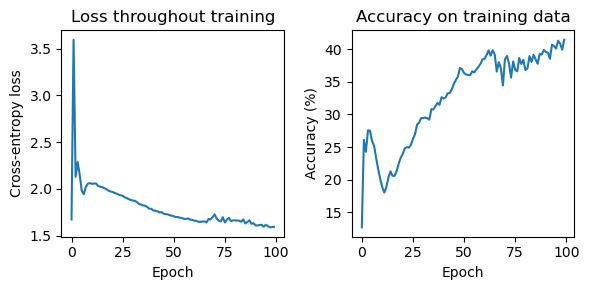

In [154]:
utils.plot_performance_training(losses, accuracies)

We should investigate if the model performs better if we train it longer. But training a model with many parameters for many epochs on a fairly complex dataset takes a lot of time, especially without GPUs. Therefore, we have pretrained a model with a 100 neurons in the hidden layer for 10000 epochs that you can load together with the loss and accuracy throughout training by running the cell below.

In [88]:
# Load model
model = torch.load(f'model_single_layer_{hidden_layer_size}_hidden_neurons_10000epochs.pth', weights_only=False)
print("Model loaded successfully")

df = pd.read_csv('train_performance_100hidden_10000epochs.csv')
losses = df['losses']
accuracies = df['accuracies']
print('Loss and accuracy throughout training loaded successfully')
model

Model loaded successfully
Loss and accuracy throughout training loaded successfully


Sequential(
  (0): Linear(in_features=3072, out_features=100, bias=True)
  (1): ReLU()
  (2): Linear(in_features=100, out_features=10, bias=True)
)

**Exercise**: Plot the loss and the accuracy throughout training loaded for the model with a 100 neurons that was trained for 10000 epochs.

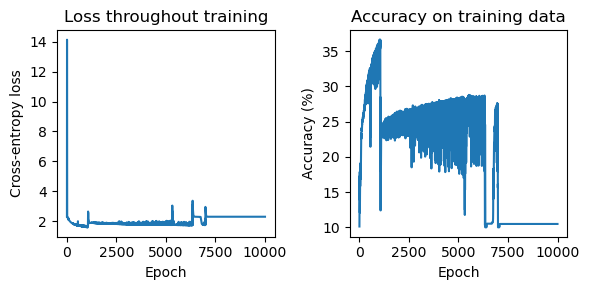

In [89]:
utils.plot_performance_training(losses, accuracies)

When the loaded model was trained for 10000 epochs, the loss decreased for a while, then it started increasing again. The accuracy also increased for a while, before it started dropping.

Let's load a model that was only trained for 1000 epochs.

In [90]:
# Load model
model = torch.load(f'model_single_layer_{hidden_layer_size}_hidden_neurons_1000epochs.pth', weights_only=False)
print("Model loaded successfully")

df = pd.read_csv('train_performance_100hidden_1000epochs.csv')
losses = df['losses']
accuracies = df['accuracies']
print('Loss and accuracy throughout training loaded successfully')
model

Model loaded successfully
Loss and accuracy throughout training loaded successfully


Sequential(
  (0): Linear(in_features=3072, out_features=100, bias=True)
  (1): ReLU()
  (2): Linear(in_features=100, out_features=10, bias=True)
)

**Exercise**: Plot the loss and the accuracy throughout training loaded for the model with a 100 neurons that was trained for 10000 epochs.

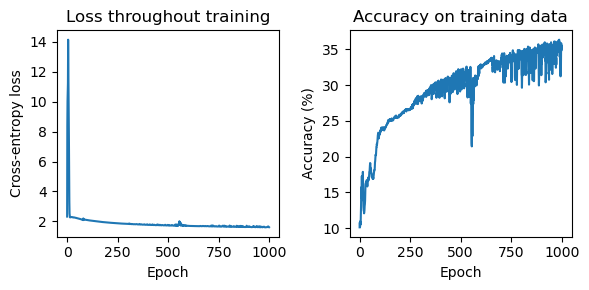

In [91]:
utils.plot_performance_training(losses, accuracies)

The plot in the previous exercise only shows the accuracy on the data that the model was trained on. It could be that the model only memorizes patterns specific to the training dataset instead of generalizable patterns. To investigate whether the model generalizes, we should also calculate the accuracy on data that the model didn't see during training. This subdataset is referred to as the test dataset. If the accuracy is low on the test dataset (and substantially lower than the accuracy on the training data), that suggests that the model does not generalize well.


**Exercise**: Calculate the accuracy of the loaded model on the test dataset (`features_test` and `labels_test`). Feel free to use the utility function `utils.calculate_accuracy`.

In [93]:
utils.calculate_accuracy(model, features_test, labels_test)

Accuracy: 10.0


10.0

## Section 2: Effect of Making Networks Deeper

Run cell below to define number of input features and number of classes to classify for models in this section and to create the SEED.

In [94]:
n_in_features = 32 * 32 * 3  # CIFAR-10 images flattened
n_classes = 10  # CIFAR-10 has 10 classes
SEED = 2026

**Example**: Create a model with two hidden layers and 10 neurons in each hidden layer (`hidden_layer_size = 10`) and a ReLU activation function after each the hidden layer.

In [97]:
hidden_layer_size = 10

# create model
torch.manual_seed(SEED)

model = nn.Sequential(
    nn.Linear(n_in_features, hidden_layer_size),
    nn.ReLU(),
    nn.Linear(hidden_layer_size, hidden_layer_size),
    nn.ReLU(),
    nn.Linear(hidden_layer_size, n_classes)
)
model

Sequential(
  (0): Linear(in_features=3072, out_features=10, bias=True)
  (1): ReLU()
  (2): Linear(in_features=10, out_features=10, bias=True)
  (3): ReLU()
  (4): Linear(in_features=10, out_features=10, bias=True)
)

Train the model for 50 epochs using `utils.train`. Run the second cell to plot the accuracy and loss throughout training.

In [98]:
losses, accuracies = utils.train(model, features_train, labels_train, nepochs=50)

 22%|██▏       | 11/50 [00:00<00:00, 53.96it/s]

Epoch: 0, Loss: 2.32, Train accuracy: 10.00
Epoch: 10, Loss: 2.29, Train accuracy: 9.72


 64%|██████▍   | 32/50 [00:00<00:00, 62.07it/s]

Epoch: 20, Loss: 2.25, Train accuracy: 14.84
Epoch: 30, Loss: 2.18, Train accuracy: 19.84


100%|██████████| 50/50 [00:00<00:00, 56.61it/s]

Epoch: 40, Loss: 2.11, Train accuracy: 20.80


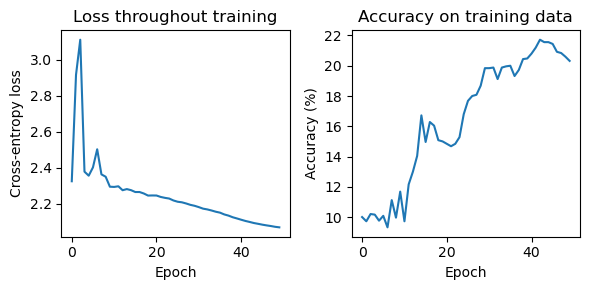

In [99]:
utils.plot_performance_training(losses, accuracies)

**Exercise**: Create a model with 4 hidden layers and 10 neurons in each hidden layer (`hidden_layer_size = 10`) and a ReLU activation function after each the hidden layer.

In [134]:
hidden_layer_size = 10

# create model
torch.manual_seed(SEED)

model = nn.Sequential(
    nn.Linear(n_in_features, hidden_layer_size),
    nn.ReLU(),
    nn.Linear(hidden_layer_size, hidden_layer_size),
    nn.ReLU(),
    nn.Linear(hidden_layer_size, hidden_layer_size),
    nn.ReLU(),
    nn.Linear(hidden_layer_size, hidden_layer_size),
    nn.ReLU(),
    nn.Linear(hidden_layer_size, n_classes)
)
model

Sequential(
  (0): Linear(in_features=3072, out_features=10, bias=True)
  (1): ReLU()
  (2): Linear(in_features=10, out_features=10, bias=True)
  (3): ReLU()
  (4): Linear(in_features=10, out_features=10, bias=True)
  (5): ReLU()
  (6): Linear(in_features=10, out_features=10, bias=True)
  (7): ReLU()
  (8): Linear(in_features=10, out_features=10, bias=True)
)

Train the model for 50 epochs using `utils.train`. Run the second cell to plot the accuracy and loss throughout training.

In [135]:
losses, accuracies = utils.train(model, features_train, labels_train, nepochs=50)

  1%|          | 11/1000 [00:00<00:19, 50.83it/s]

Epoch: 0, Loss: 2.32, Train accuracy: 10.00
Epoch: 10, Loss: 2.21, Train accuracy: 16.40


  3%|▎         | 30/1000 [00:00<00:17, 54.11it/s]

Epoch: 20, Loss: 2.10, Train accuracy: 19.84
Epoch: 30, Loss: 2.04, Train accuracy: 22.48


  4%|▍         | 42/1000 [00:00<00:26, 36.36it/s]

...

 98%|█████████▊| 985/1000 [00:28<00:00, 36.51it/s]

Epoch: 980, Loss: 1.46, Train accuracy: 38.16


100%|█████████▉| 997/1000 [00:29<00:00, 36.17it/s]

Epoch: 990, Loss: 1.41, Train accuracy: 44.24


100%|██████████| 1000/1000 [00:29<00:00, 34.34it/s]


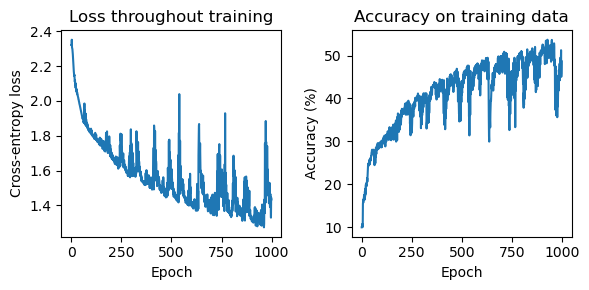

In [136]:
utils.plot_performance_training(losses, accuracies)

The models with 4 hidden layers reached a higher accuracy on the training data than the model with a single layer and 100 neurons for the same number of epochs. To save you some time, we've pretrained the same model for a 1000 epochs, which you can load together with the accuracy and losses throughout training by running the cell below.

In [119]:
nlayers = 4
hidden_layer_size = 10
nepochs = 1000

# Load model
model = torch.load(f'model_{nlayers}layers_{hidden_layer_size}hidden_neurons_{nepochs}epochs.pth', weights_only=False)
print("Model loaded successfully")

df = pd.read_csv(f'train_performance_{nlayers}layers_{hidden_layer_size}hidden_{nepochs}epochs.csv')
losses = df['losses']
accuracies = df['accuracies']
print('Loss and accuracy throughout training loaded successfully')
model

Model loaded successfully
Loss and accuracy throughout training loaded successfully


Sequential(
  (0): Linear(in_features=3072, out_features=10, bias=True)
  (1): ReLU()
  (2): Linear(in_features=10, out_features=10, bias=True)
  (3): ReLU()
  (4): Linear(in_features=10, out_features=10, bias=True)
  (5): ReLU()
  (6): Linear(in_features=10, out_features=10, bias=True)
  (7): ReLU()
  (8): Linear(in_features=10, out_features=10, bias=True)
)

**Exercise**: Plot the loss and the accuracy throughout training loaded for the model with a 4 layers of 10 neurons that was trained for 1000 epochs.

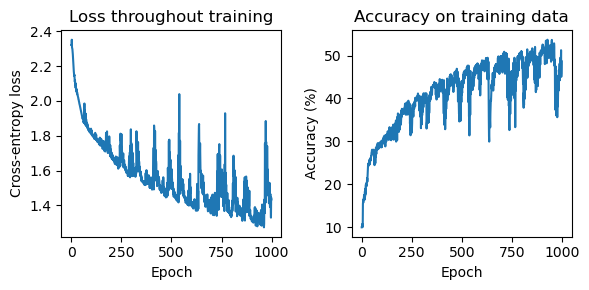

In [120]:
utils.plot_performance_training(losses, accuracies)

The model with 4 layers trained over 1000 epochs reached an even higher train accuracy.

**Exercise**: Try increasing the number of hidden layers to 8, still with 10 neurons per layer. 


As long as the hidden layers are followed by the same activation function - in this case ReLU - we can write it in a loop so

In [138]:
hidden_layer_size = 10

# create model
torch.manual_seed(SEED)

model = nn.Sequential(
    nn.Linear(n_in_features, hidden_layer_size),
    nn.ReLU(),
    nn.Linear(hidden_layer_size, hidden_layer_size),
    nn.ReLU(),
    nn.Linear(hidden_layer_size, hidden_layer_size),
    nn.ReLU(),
    nn.Linear(hidden_layer_size, hidden_layer_size),
    nn.ReLU(),
    nn.Linear(hidden_layer_size, hidden_layer_size),
    nn.ReLU(),
    nn.Linear(hidden_layer_size, hidden_layer_size),
    nn.ReLU(),
    nn.Linear(hidden_layer_size, hidden_layer_size),
    nn.ReLU(),
    nn.Linear(hidden_layer_size, hidden_layer_size),
    nn.ReLU(),
    nn.Linear(hidden_layer_size, n_classes)
)
model

Sequential(
  (0): Linear(in_features=3072, out_features=10, bias=True)
  (1): ReLU()
  (2): Linear(in_features=10, out_features=10, bias=True)
  (3): ReLU()
  (4): Linear(in_features=10, out_features=10, bias=True)
  (5): ReLU()
  (6): Linear(in_features=10, out_features=10, bias=True)
  (7): ReLU()
  (8): Linear(in_features=10, out_features=10, bias=True)
  (9): ReLU()
  (10): Linear(in_features=10, out_features=10, bias=True)
  (11): ReLU()
  (12): Linear(in_features=10, out_features=10, bias=True)
  (13): ReLU()
  (14): Linear(in_features=10, out_features=10, bias=True)
  (15): ReLU()
  (16): Linear(in_features=10, out_features=10, bias=True)
)

In [141]:
losses, accuracies = utils.train(model, features_train, labels_train, nepochs=1000)

  0%|          | 5/1000 [00:00<00:23, 42.32it/s]

Epoch: 0, Loss: 1.88, Train accuracy: 11.20


  2%|▏         | 18/1000 [00:00<00:30, 32.73it/s]

Epoch: 10, Loss: 2.23, Train accuracy: 13.52


  3%|▎         | 28/1000 [00:00<00:24, 39.09it/s]

...

 99%|█████████▉| 988/1000 [00:29<00:00, 40.34it/s]

Epoch: 980, Loss: 1.64, Train accuracy: 35.48


100%|█████████▉| 997/1000 [00:29<00:00, 35.29it/s]

Epoch: 990, Loss: 1.59, Train accuracy: 32.68


100%|██████████| 1000/1000 [00:30<00:00, 33.24it/s]


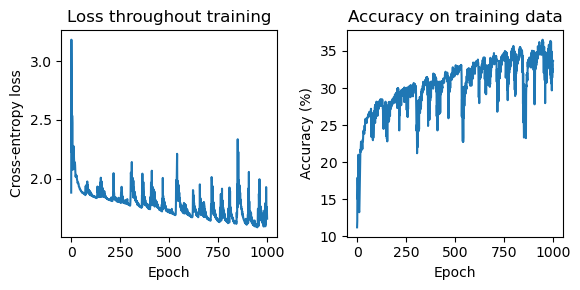

In [142]:
utils.plot_performance_training(losses, accuracies)

In [143]:
hidden_layer_size = 100

# create model
torch.manual_seed(SEED)

model = nn.Sequential(
    nn.Linear(n_in_features, hidden_layer_size),
    nn.ReLU(),
    nn.Linear(hidden_layer_size, hidden_layer_size),
    nn.ReLU(),
    nn.Linear(hidden_layer_size, hidden_layer_size),
    nn.ReLU(),
    nn.Linear(hidden_layer_size, hidden_layer_size),
    nn.ReLU(),
    nn.Linear(hidden_layer_size, n_classes)
)
model

Sequential(
  (0): Linear(in_features=3072, out_features=100, bias=True)
  (1): ReLU()
  (2): Linear(in_features=100, out_features=100, bias=True)
  (3): ReLU()
  (4): Linear(in_features=100, out_features=100, bias=True)
  (5): ReLU()
  (6): Linear(in_features=100, out_features=100, bias=True)
  (7): ReLU()
  (8): Linear(in_features=100, out_features=10, bias=True)
)

In [144]:
losses, accuracies = utils.train(model, features_train, labels_train, nepochs=1000)

  0%|          | 4/1000 [00:00<00:54, 18.23it/s]

Epoch: 0, Loss: 2.30, Train accuracy: 10.16


  1%|          | 12/1000 [00:00<01:09, 14.30it/s]

Epoch: 10, Loss: 2.26, Train accuracy: 14.96


  2%|▏         | 22/1000 [00:01<01:39,  9.85it/s]

...

 98%|█████████▊| 983/1000 [01:53<00:01, 10.79it/s]

Epoch: 980, Loss: 0.00, Train accuracy: 100.00


 99%|█████████▉| 992/1000 [01:54<00:00,  9.06it/s]

Epoch: 990, Loss: 0.00, Train accuracy: 100.00


100%|██████████| 1000/1000 [01:55<00:00,  8.68it/s]


In [147]:
nhidden_layers = 8
torch.save(model, f'model_{nhidden_layers}layers_{hidden_layer_size}hidden_neurons_{nepochs}epochs.pth')

train_performance = dict()
train_performance['losses'] = losses
train_performance['accuracies'] = accuracies

df = pd.DataFrame(train_performance)
df.to_csv(f'train_performance_{nhidden_layers}layers_{hidden_layer_size}hidden_{nepochs}epochs.csv')

In [148]:
nhidden_layers = 8
hidden_layer_size = 100
nepochs = 1000

# Load model
model = torch.load(f'model_{nhidden_layers}layers_{hidden_layer_size}hidden_neurons_{nepochs}epochs.pth', weights_only=False)
print("Model loaded successfully")

df = pd.read_csv(f'train_performance_{nhidden_layers}layers_{hidden_layer_size}hidden_{nepochs}epochs.csv')
losses = df['losses']
accuracies = df['accuracies']
print('Loss and accuracy throughout training loaded successfully')
model

Model loaded successfully
Loss and accuracy throughout training loaded successfully


Sequential(
  (0): Linear(in_features=3072, out_features=100, bias=True)
  (1): ReLU()
  (2): Linear(in_features=100, out_features=100, bias=True)
  (3): ReLU()
  (4): Linear(in_features=100, out_features=100, bias=True)
  (5): ReLU()
  (6): Linear(in_features=100, out_features=100, bias=True)
  (7): ReLU()
  (8): Linear(in_features=100, out_features=10, bias=True)
)

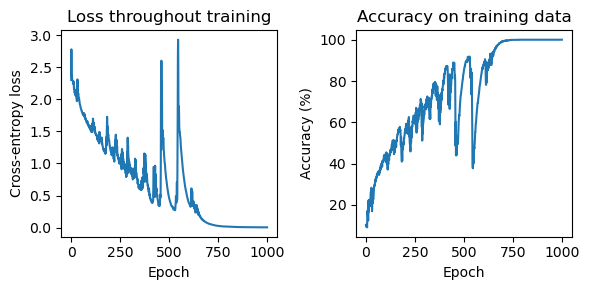

In [149]:
utils.plot_performance_training(losses, accuracies)

In [125]:
n_hidden_layers = 8

layers = []
input_size = n_in_features

for ilayer in range(nlayers):
    layers.append(nn.Linear(input_size, hidden_layer_size))
    layers.append(nn.ReLU())
    input_size = hidden_layer_size

layers.append(nn.Linear(input_size, n_classes))

model = nn.Sequential(*layers)
model

Sequential(
  (0): Linear(in_features=3072, out_features=10, bias=True)
  (1): ReLU()
  (2): Linear(in_features=10, out_features=10, bias=True)
  (3): ReLU()
  (4): Linear(in_features=10, out_features=10, bias=True)
  (5): ReLU()
  (6): Linear(in_features=10, out_features=10, bias=True)
  (7): ReLU()
  (8): Linear(in_features=10, out_features=10, bias=True)
  (9): ReLU()
  (10): Linear(in_features=10, out_features=10, bias=True)
  (11): ReLU()
  (12): Linear(in_features=10, out_features=10, bias=True)
  (13): ReLU()
  (14): Linear(in_features=10, out_features=10, bias=True)
  (15): ReLU()
  (16): Linear(in_features=10, out_features=10, bias=True)
)

In [137]:
n_features = 32 * 32 * 3  # CIFAR-10 images flattened

model = utils.create_deep_model(n_features=n_features, hidden_layer_sizes = [20]*5)

losses_deep, accuracies_deep = utils.train(model, features_train, labels_train, nepochs=1000)

  0%|          | 4/1000 [00:00<01:09, 14.24it/s]

Epoch: 0, Loss: 2.31, Train accuracy: 10.38


  1%|▏         | 14/1000 [00:00<01:00, 16.34it/s]

Epoch: 10, Loss: 2.23, Train accuracy: 17.78


  2%|▏         | 22/1000 [00:01<01:24, 11.59it/s]

...

 98%|█████████▊| 983/1000 [01:55<00:01, 10.23it/s]

Epoch: 980, Loss: 1.41, Train accuracy: 45.19


 99%|█████████▉| 993/1000 [01:56<00:00, 10.75it/s]

Epoch: 990, Loss: 1.42, Train accuracy: 47.08


100%|██████████| 1000/1000 [01:57<00:00,  8.54it/s]


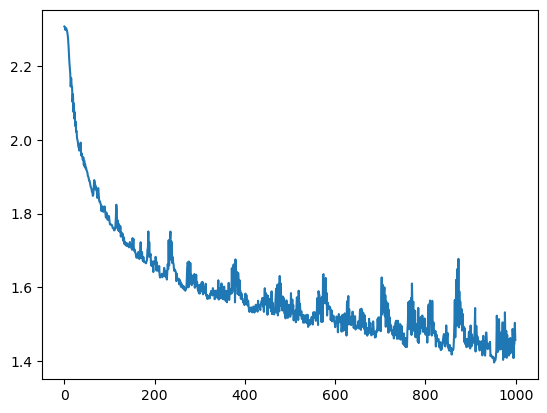

In [138]:
plt.plot(losses_deep)

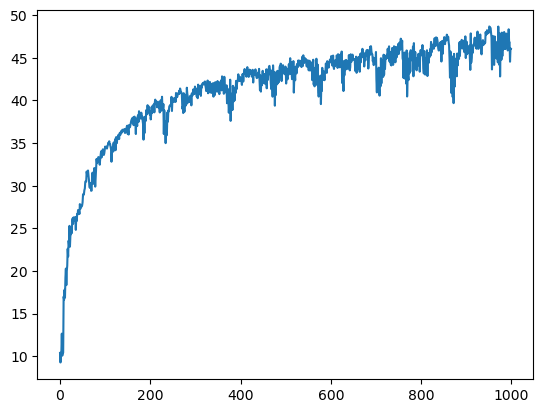

In [140]:
plt.plot(accuracies_deep)

In [141]:
accuracy = utils.calculate_accuracy(model, features_test, labels_test)
print(f"Epoch: {epoch}, Loss: {loss:.2f}, accuracy: {accuracy:.2f}")

Accuracy: 36.14999771118164
Epoch: 19, Loss: 2.26, accuracy: 36.15


## Section 3: Batch Normalization

## Section 4: Initialization Matters